# Lab: Adversarial Attacks and Adversarial Training


------------------------------------------------------
*Pablo M. Olmos pamartin@ing.uc3m.es*

------------------------------------------------------



## What is an adversarial example?

An **adversarial example** is a slightly modified input that causes a neural
network to make an incorrect prediction.

Given an input image $x$ and a classifier $f_\theta$, we search for a small
perturbation $\delta$ such that $f_\theta(x) \neq f_\theta(x + \delta)$
while keeping the perturbation imperceptibly small:

$\|\delta\|_\infty \le \varepsilon$

The adversarial image is defined as

$x_{\text{adv}} = \text{clip}(x + \delta)$

where the clipping operation ensures that pixel values remain in the valid
range (e.g. $[0,1]$).


## Threat model: White-box attacks

In this notebook we assume a **white-box attacker**, meaning:

- The model architecture is known
- The model parameters $\theta$ are known
- Gradients $\nabla_x \mathcal{L}(f_\theta(x), y)$ can be computed

This setting allows us to design efficient gradient-based attacks.


## Fast Gradient Sign Method (FGSM)

The **Fast Gradient Sign Method (FGSM)** is a single-step adversarial attack.

Given a loss function $\mathcal{L}$, the perturbation is computed as

$\delta = \varepsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x), y)\right)$

The adversarial example is then

$x_{\text{adv}} = \text{clip}(x + \delta)$

Key properties:

- Very fast (one gradient computation)
- Often sufficient to fool standard CNNs
- Serves as the basis for stronger iterative attacks


## Intuition behind FGSM

The gradient $\nabla_x \mathcal{L}(f_\theta(x), y)$ indicates how each pixel
should change to **increase the loss**.

FGSM takes the **sign** of this gradient and pushes each pixel to its maximum
allowed change $\varepsilon$ in the direction that most increases the loss.

Even though the perturbation is small, it is coordinated across all pixels,
which makes it highly effective.


## Projected Gradient Descent (PGD)

**Projected Gradient Descent (PGD)** is an iterative version of FGSM.

Starting from the original image $x^{(0)} = x$, we repeat

$x^{(t+1)} = \Pi_{B_\varepsilon(x)}\left(x^{(t)} + \alpha \cdot \text{sign}\left(\nabla_x \mathcal{L}(f_\theta(x^{(t)}), y)\right)\right)$

where:

- $\alpha$ is the step size
- $\Pi_{B_\varepsilon(x)}$ projects back onto the $\ell_\infty$ ball of radius
  $\varepsilon$ around the original image

PGD is considered a **strong first-order adversary** and is widely used for
robustness evaluation.


## Targeted vs untargeted attacks

### Untargeted attack

The goal is simply to cause **any misclassification**:

$\max_\delta \; \mathcal{L}(f_\theta(x + \delta), y)$

### Targeted attack

The goal is to force the model to predict a **specific target class**
$y_{\text{target}}$:

$\min_\delta \; \mathcal{L}(f_\theta(x + \delta), y_{\text{target}})$

Targeted attacks are typically harder and require stronger perturbations or
more iterations.


## Accuracy vs perturbation strength

A common way to evaluate adversarial robustness is to measure test accuracy
as a function of $\varepsilon$:

- $\varepsilon = 0$: clean accuracy
- Increasing $\varepsilon$: stronger attacks
- Rapid accuracy drop indicates lack of robustness

This evaluation helps visualize how fragile standard CNNs are to adversarial
perturbations.


## Key takeaways

- Adversarial examples exploit the **local linearity** of neural networks
- FGSM is fast and simple but already very effective
- PGD is stronger and often considered the "gold standard" attack
- Standard CNNs trained normally are **not robust** to adversarial noise

Adversarial robustness is an important consideration when deploying deep
learning models in safety-critical applications.


## Setup (GPU)

This notebook will use **one GPU** if available. We set `CUDA_VISIBLE_DEVICES=0` and use `cuda:0`.


In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- GPU selection: use only ONE GPU (GPU 0) ---
# Option A (recommended): set CUDA_VISIBLE_DEVICES before CUDA is initialized.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: NVIDIA GeForce RTX 4090


In [2]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),  # -> [0,1]
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# DataLoader settings
pin_memory = (device.type == "cuda")
num_workers = 4 if (os.name != "nt") else 0  # Windows often prefers 0 in notebooks
num_workers = min(num_workers, os.cpu_count() or 2)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)

x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, y0.shape)


Batch: torch.Size([128, 1, 28, 28]) torch.Size([128])


In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64*7*7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)          # 28->14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)          # 14->7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = SmallCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [4]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    return total_loss / total

@torch.no_grad()
def eval_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

# Quick training (MNIST should converge fast)
for epoch in range(3):
    loss = train_one_epoch(model, train_loader, optimizer)
    acc = eval_accuracy(model, test_loader)
    print(f"epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


epoch=1 loss=0.2290 test_acc=97.99%
epoch=2 loss=0.0623 test_acc=98.74%
epoch=3 loss=0.0406 test_acc=98.78%


In [5]:
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def predict(model, x):
    model.eval()
    logits = model(x)
    return logits.argmax(dim=1)

def show_batch(images, labels=None, preds=None, n=8, title=None):
    images = images.detach().cpu()
    n = min(n, images.size(0))
    fig, axes = plt.subplots(1, n, figsize=(1.8*n, 2.0))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i].imshow(images[i,0], cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")
        t = []
        if labels is not None: t.append(f"y={int(labels[i])}")
        if preds is not None:  t.append(f"p={int(preds[i])}")
        axes[i].set_title("\n".join(t), fontsize=10)
    if title:
        fig.suptitle(title)
    plt.show()

def l_inf_norm(x_adv, x):
    # per-sample L_inf norm
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values


In [6]:
def fgsm_attack(model, x, y, eps, targeted=False, y_target=None):
    """
    Untargeted FGSM: maximize loss wrt true label y.
    Targeted FGSM:   minimize loss wrt target label y_target.
    """
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    logits = model(x_adv)

    if targeted:
        assert y_target is not None, "Provide y_target for targeted FGSM."
        loss = F.cross_entropy(logits, y_target)
        # targeted: gradient *descent* on loss => subtract sign(grad)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv - eps * grad_sign
    else:
        loss = F.cross_entropy(logits, y)
        # untargeted: gradient *ascent* on loss => add sign(grad)
        grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
        x_adv = x_adv + eps * grad_sign

    x_adv = clamp01(x_adv.detach())
    return x_adv


Clean acc on this batch: 0.9921875
FGSM  acc on this batch: 0.59375
Max L_inf in batch: 0.15000003576278687


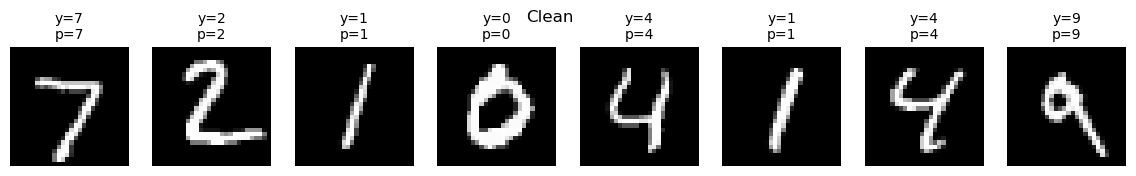

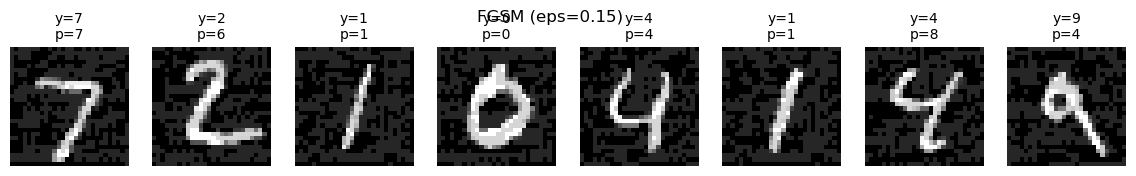

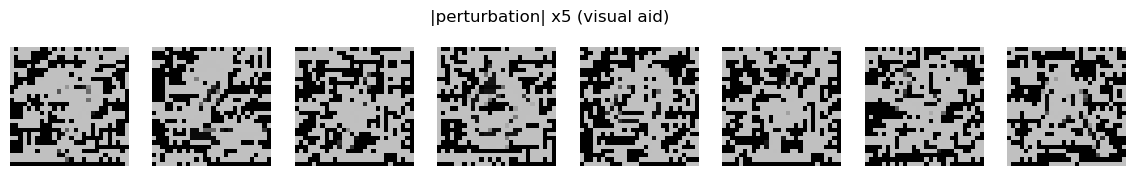

In [7]:
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    p_clean = predict(model, x)

eps = 0.15
x_fgsm = fgsm_attack(model, x, y, eps=eps, targeted=False)

with torch.no_grad():
    p_adv = predict(model, x_fgsm)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("FGSM  acc on this batch:", (p_adv == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_fgsm, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_fgsm[:8], labels=y[:8], preds=p_adv[:8], title=f"FGSM (eps={eps})")
show_batch((x_fgsm - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [8]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    PGD in L_inf ball around x.
    Untargeted: maximize CE loss wrt y.
    Targeted:   minimize CE loss wrt y_target.
    """
    model.eval()

    x_orig = x.detach()
    if random_start:
        # uniform noise in [-eps, eps]
        x_adv = x_orig + (2*torch.rand_like(x_orig) - 1.0) * eps
        x_adv = clamp01(x_adv)
    else:
        x_adv = x_orig.clone()

    for _ in range(steps):
        x_adv = x_adv.clone().detach().requires_grad_(True)
        logits = model(x_adv)

        if targeted:
            assert y_target is not None, "Provide y_target for targeted PGD."
            loss = F.cross_entropy(logits, y_target)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv - alpha * grad.sign()
        else:
            loss = F.cross_entropy(logits, y)
            grad = torch.autograd.grad(loss, x_adv)[0]
            x_adv = x_adv + alpha * grad.sign()

        # Project back to L_inf ball around x_orig
        delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
        x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


PGD acc on this batch: 0.0078125
Max L_inf in batch: 0.20000001788139343


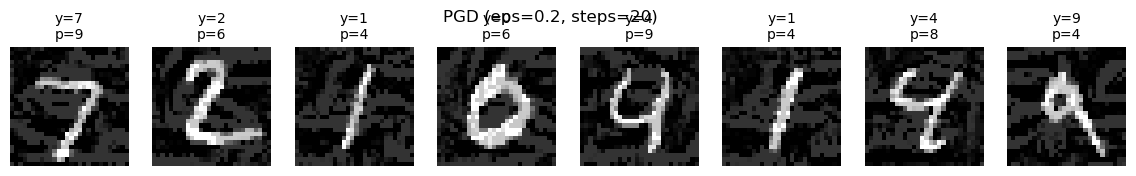

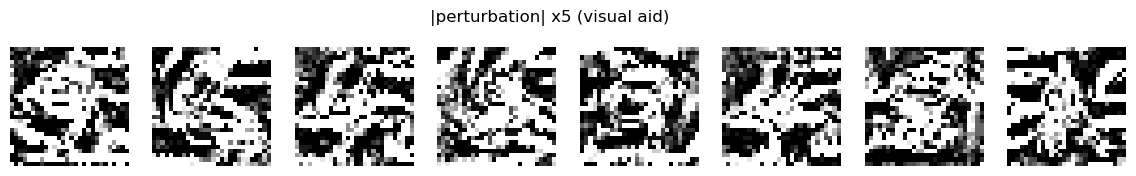

In [9]:
eps = 0.20
alpha = 0.02
steps = 20

x_pgd = pgd_attack(model, x, y, eps=eps, alpha=alpha, steps=steps, random_start=True)

with torch.no_grad():
    p_pgd = predict(model, x_pgd)

print("PGD acc on this batch:", (p_pgd == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_pgd, x).max().item())

show_batch(x_pgd[:8], labels=y[:8], preds=p_pgd[:8], title=f"PGD (eps={eps}, steps={steps})")
show_batch((x_pgd - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


In [10]:
@torch.no_grad()
def eval_clean(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

def eval_under_attack(model, loader, attack_fn):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total


In [11]:
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

clean_acc = eval_clean(model, test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=20)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.2f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.9878
eps=0.05  FGSM=95.48%  PGD=94.37%
eps=0.10  FGSM=86.02%  PGD=75.93%
eps=0.15  FGSM=65.69%  PGD=28.85%
eps=0.20  FGSM=38.78%  PGD=2.55%
eps=0.25  FGSM=15.93%  PGD=0.01%


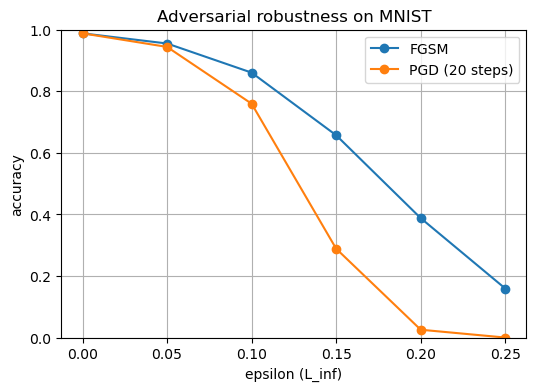

In [12]:
plt.figure(figsize=(6,4))
plt.plot(eps_list, fgsm_accs, marker="o", label="FGSM")
plt.plot(eps_list, pgd_accs,  marker="o", label="PGD (20 steps)")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Adversarial robustness on MNIST")
plt.show()


## Comparison of attacks: accuracy vs $\varepsilon$

We compare test accuracy under different **white-box** adversarial attacks as a function of the perturbation budget $\varepsilon$ (using an $\ell_\infty$ constraint).

For each $\varepsilon$ we generate adversarial examples $x_{\text{adv}}$ and report:

- **Clean accuracy** (no attack)
- **FGSM** accuracy (1-step)
- **PGD** accuracy for different numbers of steps (stronger attacks)

Typically, as $\varepsilon$ increases and as the number of PGD steps increases, accuracy decreases.

attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.988,nan,nan,nan
0.050000,0.988,0.955,0.945,0.944
0.100000,0.988,0.860,0.762,0.750
0.150000,0.988,0.657,0.301,0.255
0.200000,0.988,0.388,0.028,0.017
0.250000,0.988,0.159,0.000,0.000


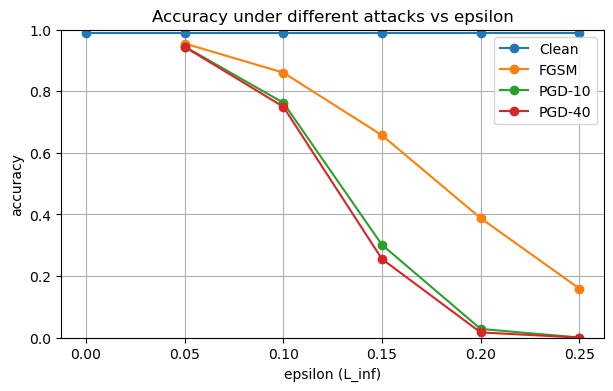

In [13]:
import pandas as pd

def attack_suite(model, eps, pgd_steps_list=(10, 40)):
    """Return a dict of attack callables x,y -> x_adv for a given eps."""
    suite = {}
    suite["Clean"] = lambda x, y: x
    if eps > 0:
        suite[f"FGSM (eps={eps:.2f})"] = lambda x, y: fgsm_attack(model, x, y, eps=eps)
        for steps in pgd_steps_list:
            # A simple default step size; feel free to experiment
            alpha = eps / 4 if eps > 0 else 0.0
            suite[f"PGD-{steps} (eps={eps:.2f})"] = lambda x, y, a=alpha, s=steps: pgd_attack(
                model, x, y, eps=eps, alpha=a, steps=s, random_start=True
            )
    return suite

def eval_attack_accuracy(model, loader, attack_fn):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total

def sweep_attacks(model, loader, eps_list, pgd_steps_list=(10, 40), max_batches=None):
    """Return a DataFrame with accuracy for multiple attacks across eps values."""
    rows = []
    for eps in eps_list:
        suite = attack_suite(model, eps, pgd_steps_list=pgd_steps_list)
        for name, fn in suite.items():
            # Optionally evaluate only on a subset of batches for speed
            if max_batches is None:
                acc = eval_attack_accuracy(model, loader, fn)
            else:
                model.eval()
                correct, total = 0, 0
                for bi, (x, y) in enumerate(loader):
                    if bi >= max_batches:
                        break
                    x, y = x.to(device), y.to(device)
                    x_adv = fn(x, y)
                    with torch.no_grad():
                        pred = model(x_adv).argmax(1)
                    correct += (pred == y).sum().item()
                    total += x.size(0)
                acc = correct / total
            rows.append({"epsilon": float(eps), "attack": name.split(" (eps=")[0], "accuracy": acc})
    df = pd.DataFrame(rows)
    return df

# --- run sweep (set max_batches to e.g. 50 if you want it faster) ---
eps_list = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
df_attacks = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)

# Pretty table: rows=epsilon, cols=attack
table = df_attacks.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table.style.format("{:.3f}"))

# Plot
plt.figure(figsize=(7,4))
for col in table.columns:
    plt.plot(table.index, table[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Accuracy under different attacks vs epsilon")
plt.show()


## Adversarial training (idea)

A common defense is **adversarial training**: during training, we mix clean inputs $x$ with adversarial inputs $x_{\text{adv}}$ crafted against the *current* model.

A standard formulation (Madry-style) is:

$\min_\theta \; \mathbb{E}_{(x,y)}\left[ \max_{\|\delta\|_\infty \le \varepsilon} \mathcal{L}(f_\theta(x+\delta), y) \right]$

Interpretation:

- The **inner maximization** finds a worst-case perturbation within an $\ell_\infty$ ball (a strong attacker).
- The **outer minimization** updates the model parameters $\theta$ to reduce the loss on those worst-case examples.

In practice we approximate the inner maximization with FGSM (fast, 1-step) or PGD (stronger, multi-step).


## Simple adversarial training with FGSM

We will implement a simple version of adversarial training:

1) Take a batch $(x, y)$  
2) Create adversarial examples with FGSM: $x_{\text{adv}} = \text{clip}(x + \varepsilon \cdot \text{sign}(\nabla_x \mathcal{L}(f_\theta(x), y)))$  
3) Train on a mixture of clean and adversarial examples.

We will use a mixing coefficient $\lambda \in [0,1]$:

$\mathcal{L}_{\text{mix}} = (1-\lambda)\,\mathcal{L}(f_\theta(x), y) + \lambda\,\mathcal{L}(f_\theta(x_{\text{adv}}), y)$

Typical observations:

- Clean accuracy may drop slightly
- Robust accuracy (under attack) improves substantially


In [14]:
adv_model = SmallCNN().to(device)
adv_opt = torch.optim.Adam(adv_model.parameters(), lr=1e-3)


In [15]:
def train_one_epoch_adv_fgsm(model, loader, optimizer, eps, lam=0.5):
    """
    Simple adversarial training:
    loss = (1-lam)*CE(clean) + lam*CE(adv)
    where adv is generated using FGSM on the current model.
    """
    model.train()
    total_loss, total = 0.0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # --- generate adversarial examples (using current model) ---
        # We generate x_adv in "eval-style" but gradients wrt x are required.
        x_adv = fgsm_attack(model, x, y, eps=eps, targeted=False)

        # --- compute mixed loss and update parameters ---
        optimizer.zero_grad()
        logits_clean = model(x)
        logits_adv   = model(x_adv)

        loss_clean = F.cross_entropy(logits_clean, y)
        loss_adv   = F.cross_entropy(logits_adv, y)

        loss = (1 - lam) * loss_clean + lam * loss_adv
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

    return total_loss / total


In [16]:
adv_eps = 0.20   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 3

for epoch in range(epochs):
    loss = train_one_epoch_adv_fgsm(adv_model, train_loader, adv_opt, eps=adv_eps, lam=lam)
    clean_acc = eval_clean(adv_model, test_loader)
    print(f"[adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={clean_acc*100:.2f}%")


[adv-train] epoch=1 loss=0.5306 clean_test_acc=97.94%
[adv-train] epoch=2 loss=0.2285 clean_test_acc=98.55%
[adv-train] epoch=3 loss=0.1672 clean_test_acc=98.75%


## Standard vs adversarially trained: accuracy vs $\varepsilon$

Now we compare the **standard** model (trained on clean data) with the **adversarially trained** model.

We evaluate accuracy under the same set of attacks for each perturbation budget $\varepsilon$:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40

This illustrates the typical trade-off: adversarial training improves robustness (especially to the attack used in training), often at the cost of some clean accuracy.

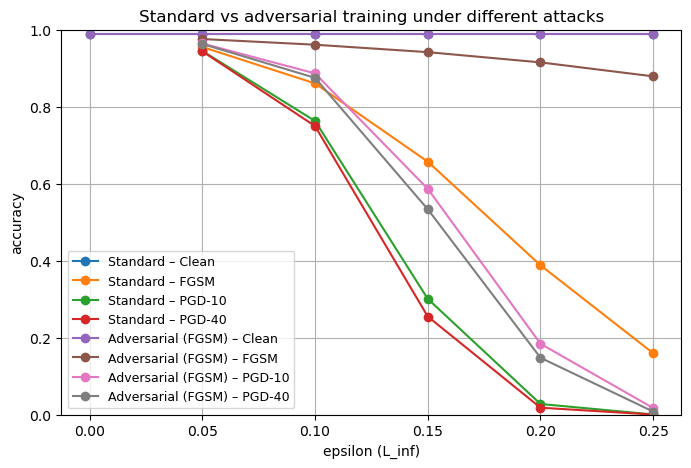

In [17]:
# Run the same sweep for both models and compare side-by-side

df_std = sweep_attacks(model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_std["training"] = "Standard"

df_adv = sweep_attacks(adv_model, test_loader, eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_adv["training"] = "Adversarial (FGSM)"

df_all = pd.concat([df_std, df_adv], ignore_index=True)

# Table: rows = (training, epsilon), cols = attack, values = accuracy
table2 = df_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table2.style.format("{:.3f}"))

# Plot: one curve per (training, attack)
plt.figure(figsize=(8,5))
for training in df_all["training"].unique():
    sub = df_all[df_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} – {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("Standard vs adversarial training under different attacks")
plt.show()


# CIFAR-10: repeat the same experiments

So far we used MNIST (grayscale, $28\times 28$). Now we repeat the same workflow on **CIFAR-10** (RGB, $32\times 32$):

1) Train a standard CNN on clean CIFAR-10  
2) Evaluate robustness vs $\varepsilon$ for FGSM and PGD  
3) Train an adversarially trained CNN (FGSM adversarial training)  
4) Compare robustness curves: standard vs adversarial training

Notes:
- We keep inputs in the pixel range $[0,1]$ (no dataset normalization) so the clipping/projection steps are the same as in MNIST.
- CIFAR-10 is harder than MNIST, so accuracy will be lower for a small CNN trained for only a few epochs.


In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# CIFAR-10 in [0,1]
cifar_transform = transforms.Compose([transforms.ToTensor()])

cifar_train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_transform)
cifar_test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_transform)

# DataLoader stability: use num_workers=0 (safe on macOS / Python 3.12)
cifar_train_loader = DataLoader(cifar_train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
cifar_test_loader  = DataLoader(cifar_test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

cifar_classes = cifar_train_ds.classes
cifar_classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [20]:
class SmallCIFARCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.fc1   = nn.Linear(256 * 2 * 2, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)   # 32 -> 16
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)   # 16 -> 8
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)   # 8 -> 4
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)   # 4 -> 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cifar_model = SmallCIFARCNN().to(device)
cifar_opt = torch.optim.Adam(cifar_model.parameters(), lr=1e-3)


In [21]:
# Train a few epochs (increase epochs for better accuracy)
cifar_epochs = 5
for epoch in range(cifar_epochs):
    loss = train_one_epoch(cifar_model, cifar_train_loader, cifar_opt)
    acc = eval_clean(cifar_model, cifar_test_loader)
    print(f"[CIFAR-10 clean] epoch={epoch+1} loss={loss:.4f} test_acc={acc*100:.2f}%")


[CIFAR-10 clean] epoch=1 loss=1.6460 test_acc=53.93%
[CIFAR-10 clean] epoch=2 loss=1.1499 test_acc=61.67%
[CIFAR-10 clean] epoch=3 loss=0.9429 test_acc=67.13%
[CIFAR-10 clean] epoch=4 loss=0.7919 test_acc=70.98%
[CIFAR-10 clean] epoch=5 loss=0.6872 test_acc=71.59%


## CIFAR-10 robustness: accuracy vs $\varepsilon$ (different attacks)

We evaluate the clean-trained CIFAR-10 model under the same attacks:

- Clean (no attack)
- FGSM
- PGD-10
- PGD-40

attack,Clean,FGSM,PGD-10,PGD-40
epsilon,,,,
0.000000,0.716,nan,nan,nan
0.001961,0.716,0.630,0.625,0.625
0.003922,0.716,0.542,0.524,0.521
0.007843,0.716,0.397,0.340,0.328
0.015686,0.716,0.195,0.100,0.086
0.031373,0.716,0.054,0.004,0.002


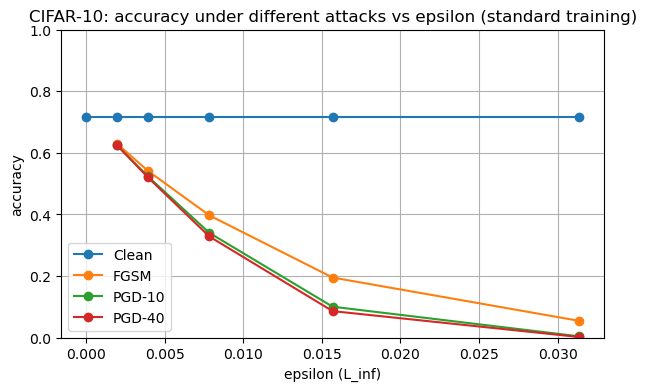

In [22]:
# Sweep attacks for the CIFAR-10 clean-trained model
cifar_eps_list = [0.0, 0.5/255, 1/255, 2/255, 4/255, 8/255]  # common CIFAR scales
df_cifar_std = sweep_attacks(cifar_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_std["training"] = "Standard"

table_cifar_std = df_cifar_std.pivot_table(index="epsilon", columns="attack", values="accuracy")
display(table_cifar_std.style.format("{:.3f}"))

plt.figure(figsize=(7,4))
for col in table_cifar_std.columns:
    plt.plot(table_cifar_std.index, table_cifar_std[col], marker="o", label=col)
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("CIFAR-10: accuracy under different attacks vs epsilon (standard training)")
plt.show()


## CIFAR-10 adversarial training (FGSM)

We adversarially train a second CIFAR-10 model using FGSM examples with a fixed budget $\varepsilon$.

We then compare robustness curves: standard vs adversarial training.


In [23]:
cifar_adv_model = SmallCIFARCNN().to(device)
cifar_adv_opt = torch.optim.Adam(cifar_adv_model.parameters(), lr=1e-3)

cifar_adv_eps = 8/255   # typical training budget on CIFAR-10
cifar_lam = 0.5
cifar_adv_epochs = 5

for epoch in range(cifar_adv_epochs):
    loss = train_one_epoch_adv_fgsm(cifar_adv_model, cifar_train_loader, cifar_adv_opt, eps=cifar_adv_eps, lam=cifar_lam)
    acc = eval_clean(cifar_adv_model, cifar_test_loader)
    print(f"[CIFAR-10 adv-train] epoch={epoch+1} loss={loss:.4f} clean_test_acc={acc*100:.2f}%")


[CIFAR-10 adv-train] epoch=1 loss=1.9624 clean_test_acc=45.12%
[CIFAR-10 adv-train] epoch=2 loss=1.6903 clean_test_acc=53.03%
[CIFAR-10 adv-train] epoch=3 loss=1.5823 clean_test_acc=56.49%
[CIFAR-10 adv-train] epoch=4 loss=1.5092 clean_test_acc=58.28%
[CIFAR-10 adv-train] epoch=5 loss=1.4561 clean_test_acc=59.22%


## CIFAR-10: standard vs adversarial training (side-by-side)

Same evaluation as before, but now comparing both CIFAR-10 models.


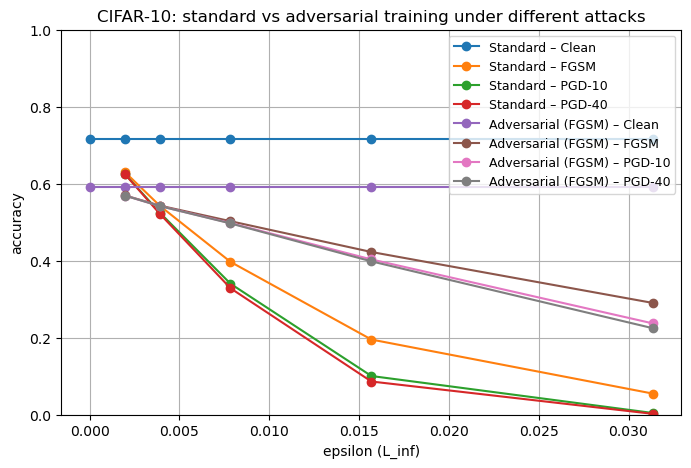

In [24]:
df_cifar_adv = sweep_attacks(cifar_adv_model, cifar_test_loader, cifar_eps_list, pgd_steps_list=(10, 40), max_batches=None)
df_cifar_adv["training"] = "Adversarial (FGSM)"

df_cifar_all = pd.concat([df_cifar_std, df_cifar_adv], ignore_index=True)

table_cifar = df_cifar_all.pivot_table(index=["training", "epsilon"], columns="attack", values="accuracy")
display(table_cifar.style.format("{:.3f}"))

plt.figure(figsize=(8,5))
for training in df_cifar_all["training"].unique():
    sub = df_cifar_all[df_cifar_all["training"] == training]
    for attack in sub["attack"].unique():
        sub2 = sub[sub["attack"] == attack].sort_values("epsilon")
        plt.plot(sub2["epsilon"], sub2["accuracy"], marker="o", label=f"{training} – {attack}")

plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend(fontsize=9)
plt.title("CIFAR-10: standard vs adversarial training under different attacks")
plt.show()
